# Zomato Delhi — EDA (Case study: Khuyến mãi)

Phân tích khám phá dữ liệu, trả lời Business Question #7–9 về khuyến mãi. Cần chạy 02a_zomato_cleaning trước.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
pd.set_option('display.max_columns', 50)

## ĐƯỜNG DẪN

In [2]:
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd().resolve().parent
CLEAN_PATH = BASE_DIR / 'data' / 'clean' / 'zomato_clean.csv'
CHARTS_DIR = BASE_DIR / 'outputs' / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

## 1. ĐỌC DỮ LIỆU ĐÃ LÀM SẠCH

In [3]:
# Cần chạy 02a_zomato_cleaning trước để có file này
df = pd.read_csv(CLEAN_PATH, parse_dates=['Order Placed At'])
df['has_discount'] = df['has_discount'].astype(bool)  # CSV lưu True/False dạng chữ, ép lại kiểu bool
print("Shape dữ liệu đã làm sạch:", df.shape)

# Chỉ tính Revenue/AOV trên đơn thành công (Delivered)
df_delivered = df[df['Order Status'] == 'Delivered'].copy()
print(f"Số đơn 'Delivered' dùng để tính Revenue/AOV: {len(df_delivered)} / {len(df)}")

Shape dữ liệu đã làm sạch: (21321, 27)
Số đơn 'Delivered' dùng để tính Revenue/AOV: 21131 / 21321


## Q7: KHUYẾN MÃI CÓ LÀM TĂNG SỐ LƯỢNG ĐƠN HÀNG KHÔNG?


=== Số lượng đơn theo có/không khuyến mãi (đơn Delivered) ===
has_discount
False     8217
True     12914
dtype: int64


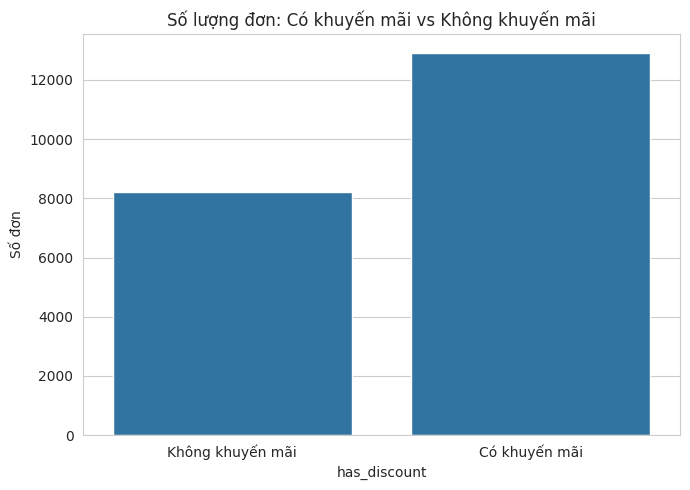

In [4]:
orders_by_discount = df_delivered.groupby('has_discount').size()
print("\n=== Số lượng đơn theo có/không khuyến mãi (đơn Delivered) ===")
print(orders_by_discount)

plt.figure(figsize=(7, 5))
sns.barplot(x=orders_by_discount.index.map({True: 'Có khuyến mãi', False: 'Không khuyến mãi'}),
            y=orders_by_discount.values)
plt.title('Số lượng đơn: Có khuyến mãi vs Không khuyến mãi')
plt.ylabel('Số đơn')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_orders_by_discount.png', dpi=120)
plt.show()
plt.close()

## Q8: KHUYẾN MÃI CÓ LÀM GIẢM AOV KHÔNG?


=== AOV theo có/không khuyến mãi (đơn Delivered) ===
has_discount
False    710.017024
True     665.105302
Name: Total, dtype: float64

Tương quan Tổng khuyến mãi vs Bill subtotal: 0.504


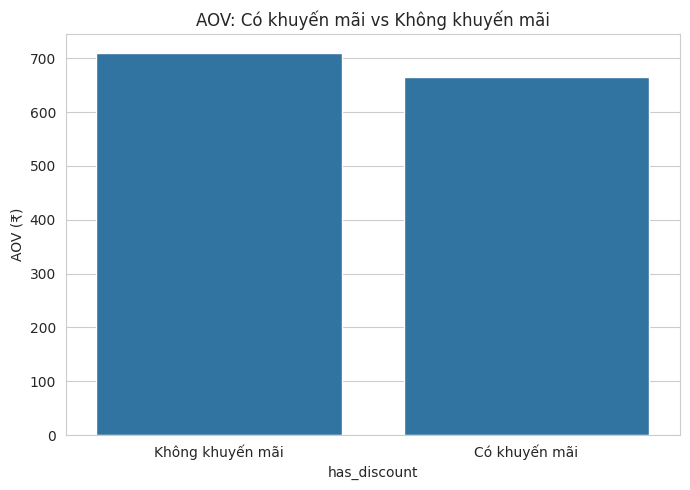

In [5]:
aov_by_discount = df_delivered.groupby('has_discount')['Total'].mean()
print("\n=== AOV theo có/không khuyến mãi (đơn Delivered) ===")
print(aov_by_discount)

corr_discount_bill = df_delivered['total_discount'].corr(df_delivered['Bill subtotal'])
print(f"\nTương quan Tổng khuyến mãi vs Bill subtotal: {corr_discount_bill:.3f}")

plt.figure(figsize=(7, 5))
sns.barplot(x=aov_by_discount.index.map({True: 'Có khuyến mãi', False: 'Không khuyến mãi'}),
            y=aov_by_discount.values)
plt.title('AOV: Có khuyến mãi vs Không khuyến mãi')
plt.ylabel('AOV (₹)')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_aov_by_discount.png', dpi=120)
plt.show()
plt.close()

## Q9: ĐƠN HỦY/TỪ CHỐI CÓ LIÊN QUAN ĐẾN KPT DURATION KHÔNG?


=== Thời gian chuẩn bị (KPT) trung bình theo Trạng thái đơn ===
Order Status
Picked up           19.590000
Delivered           17.339428
Returned            16.673600
Rejected            15.516721
Return cancelled    12.366667
Timed out                 NaN
Name: KPT duration (minutes), dtype: float64


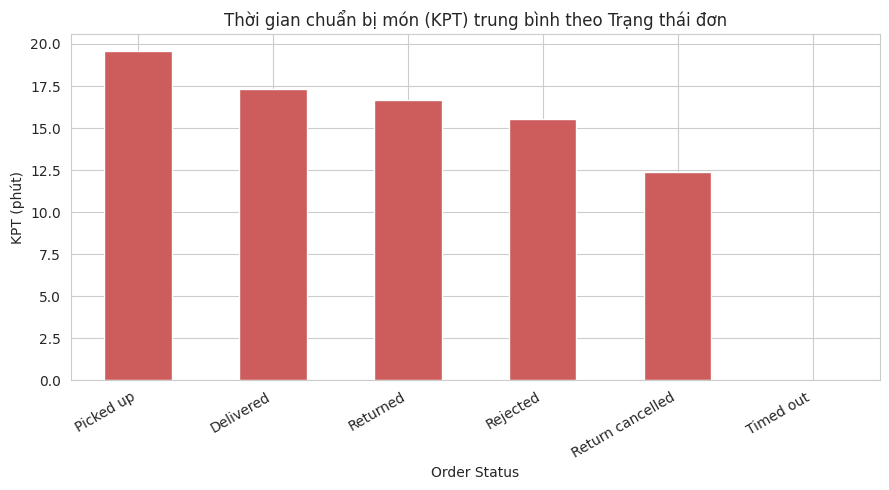


=== Phân bố Order Status (%) ===
Order Status
Delivered           99.108860
Rejected             0.741053
Returned             0.117255
Return cancelled     0.014071
Picked up            0.014071
Timed out            0.004690
Name: proportion, dtype: float64

=== HOÀN TẤT EDA ZOMATO ===
Các biểu đồ đã lưu vào outputs/charts/


In [6]:
status_kpt = df.groupby('Order Status')['KPT duration (minutes)'].mean().sort_values(ascending=False)
print("\n=== Thời gian chuẩn bị (KPT) trung bình theo Trạng thái đơn ===")
print(status_kpt)

plt.figure(figsize=(9, 5))
status_kpt.plot(kind='bar', color='indianred')
plt.title('Thời gian chuẩn bị món (KPT) trung bình theo Trạng thái đơn')
plt.ylabel('KPT (phút)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_kpt_by_status.png', dpi=120)
plt.show()
plt.close()

order_status_dist = df['Order Status'].value_counts(normalize=True) * 100
print("\n=== Phân bố Order Status (%) ===")
print(order_status_dist)

print("\n=== HOÀN TẤT EDA ZOMATO ===")
print("Các biểu đồ đã lưu vào outputs/charts/")